# TP4 bis !  Greedy + Aposteriori errors

In [ ]:
#Install package
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install scikit-fem

In [13]:
# import packages

import skfem  # for Finite Element Method
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import random
from scipy.sparse.linalg import factorized
import time

 ============================================================
 
## POD-Galerkin vs Greedy-Galerkin with FEM
###  Poisson equation  / thermal stationary conduction

 Elliptic diffusion problem (2D) with scikit-fem:
 
   $ -\nabla \cdot ( A(x,\mu) \nabla u) = g(x)  \ \mathrm{ on }\ (0, 1)^2$ 
   
$    u(0) = u(1) = 0  (Dirichlet)$

-------------------
    
    FEM:
 
 Find $u_h = \sum_{i=1}^{\mathcal{N}} u_i w_i$ such that :

   $a(u_h,v_h;\mu)=l(v_h), \ \forall v_h \in V_h$

 with Dirichlet boundary $u=0$ on $\partial \Omega$.

 Here $\Omega=[0,1] \times [0,1] = \Omega_1 \cup \Omega_2 \cup \Omega_3 \cup \Omega_4$. We use a uniform Delaunay mesh, with $Nx \times Ny$ degrees of freedom.
 
$A(x,\mu)= \mu_i $  in $ \Omega_i$

with $\mu_i \in [1,10]$ 


$g=1$

--------
#### 1) Complete the code and solve the problem for mu =[1,2,3,4]

Time : 0.008614778518676758 secondes


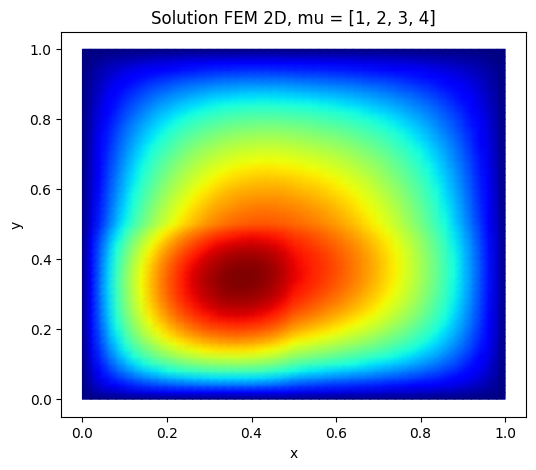

In [2]:
"""
Elliptic diffusion problem (2D) with scikit-fem:

$ -\nabla \cdot ( A(x,\mu) \nabla u) = g(x)  \ \mathrm{ on }\ (0, 1)^2$ 
$    u(0) = u(1) = 0  (Dirichlet)$

"""

import numpy as np
import matplotlib.pyplot as plt

from skfem import MeshTri, Basis, asm, enforce,solve
from skfem.element import ElementTriP1
from skfem.helpers import dot, grad
from skfem.assembly import BilinearForm, LinearForm
from skfem import solve

# -----------------------
# Problem setup
# -----------------------

Nx = 50
Ny = 50

# Maillage triangulaire du carré (0,1)^2
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)

basis = Basis(m, ElementTriP1())

# Dirichlet boundary DOFs 
D = basis.get_dofs().all()  # all dofs


def get_interior_dofs(basis):
    """
    Interior DDL ( since test functions in H^1_0)
    """
    D = basis.get_dofs().all()
    I = np.setdiff1d(np.arange(basis.N), D)
    return I
    
# l2 scalar product in 2D
@BilinearForm
def massMatrix(u, v, _):
    return ...


# -----------------------
# RHS: g = 1
# -----------------------
@LinearForm
def rhs(v, w):
    return ...

# -----------------------
# Bilinear form
# -----------------------
@BilinearForm
def diffusion(u, v, w):
    return  ...
    
@BilinearForm
def diffusion_1_1(u, v, w):
    # contribution sur Omega_1 = {x < 0.5}
    chi11 = ((w.x[0] < 0.5) & (w.x[1] < 0.5)).astype(float)
    return ...

@BilinearForm
def diffusion_1_2(u, v, w):
    # contribution sur Omega_1 = {x < 0.5}
    chi12 = ((w.x[0] >= 0.5) & (w.x[1] < 0.5)).astype(float)
    return ...

@BilinearForm
def diffusion_2_1(u, v, w):
    # contribution sur Omega_1 = {x < 0.5}
    chi21 = ((w.x[0] < 0.5) & (w.x[1] >= 0.5)).astype(float)
    return ...


@BilinearForm
def diffusion_2_2(u, v, w):
    # contribution sur Omega_2 = {x >= 0.5}
    chi22 = ((w.x[0] >= 0.5) & (w.x[1] >= 0.5)).astype(float)
    return ...

# -----------------------
# Assembly
# -----------------------
def FEMassembling(m):
    basis = Basis(m, ElementTriP1())
    A11 = ...   # on Omega_11
    A12 = ...   # on Omega_12
    A21 = ...   # on Omega_21
    A22 = ...  # on Omega_22
    
    b = ...             #  g = 1
    
    return A11,A12,A21,A22, b, basis


# -----------------------
# Solve
# -----------------------
def FEMsolve(A11,A12,A21, A22, b, basis, mu):
    A = ... #Assembling with parameter

    A_bc, b_bc = ... # Dirichlet 
    u = ... #solve
    
    return u



# -----------------------
# Example
# -----------------------
mu =[1,2,3,4]
A11,A12,A21,A22, b, basis = FEMassembling(m)
                                                                                                                   
start = time.time()                                                                                                             
                                                                                                    
u = FEMsolve(A11,A12,A21,A22,  b, basis, mu)
end = time.time()  
print("Time :", end - start, "secondes")

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6, 5))
m.plot(u, ax=ax, shading='gouraud')
ax.set_title(f"Solution FEM 2D, mu = {mu}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

#### 2) Complete POD (Construct_RB) and draw the first two reduced basis functions

In [3]:
############
""" POD """
############ 

def Construct_RB(NumberOfSnapshots=100,NumberOfModes=20,m=m):

    ...

    # orthogonality test
    return ReducedBasis

eigenvalues:  [1.46494815e-02 3.20452101e-04 2.33796072e-04 1.46100924e-04
 1.08211182e-05 7.13138380e-06]


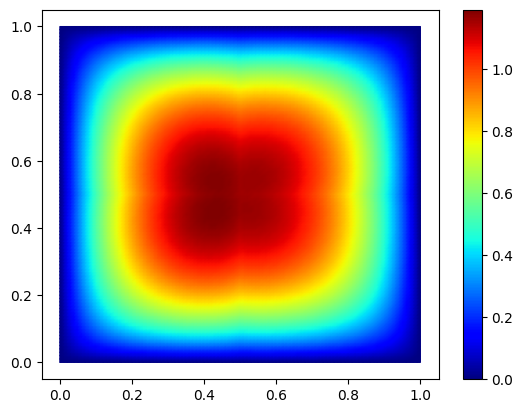

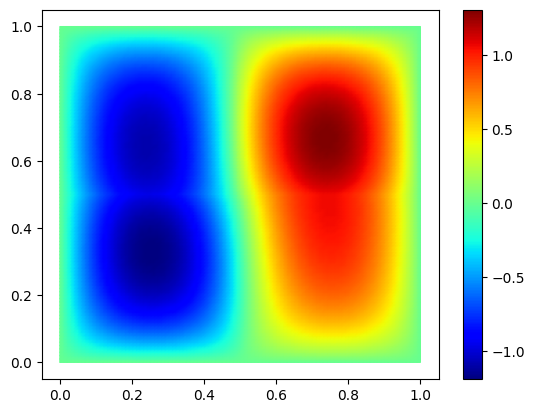

In [4]:
Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)

Phi=Construct_RB(NumberOfSnapshots=100,NumberOfModes=6,m=m)
ReducedBasis=Phi.T              

fig, ax = plt.subplots()

im=m.plot(ReducedBasis[:,0], ax=ax, shading='gouraud',colorbar=True)
fig, ax = plt.subplots()

m.plot(ReducedBasis[:,1], ax=ax, shading='gouraud',colorbar=True)

plt.show()

#### 3) Complete Strong Greedy (Construct_RB_greedy) and draw the first two reduced basis functions

In [5]:
#####################
""" Strong Greedy """
#####################


def Construct_RB_greedy(NumberOfSnapshots=100,NumberOfModes=20,m=m):
    print("strong Greedy")
    basis = Basis(m, ElementTriP1())
    L2=massMatrix.assemble(basis)
    A11,A12,A21,A22, b, basis = FEMassembling(m)

    Snapshots=[]
    for i in range(NumberOfSnapshots):
        mu = ...  #random coefficients in [1, 10] 
        U = ...
        Snapshots.append(U)
        
    ReducedBasis=np.zeros((NumberOfModes,np.shape(U)[0])) #initialization
    ReducedBasis[0,:]=... #first basis function = random first parameter or first snapshot in the list normalized
    selected_indices=[...] # Index selected in NumberOfSnapshots
    
    List_basis=[ReducedBasis[0,:]] #list of basis functions already generated  
    L2_basis=[L2.dot(List_basis[0])] # for the scalar product a_k=(u,Phi_k)

    """
    Goal : Find j ( or mu_j)  such that 
    mu_j= argmax_j || w_j|| where w_j= u_j - sum_k (u_j,Phi_k) Phi_k
    """
    for n in range(1,NumberOfModes):
        Greedy_best_score = - 1 # Greedy_best_score = max_j || w_j|| / ||u_j|| where w_j= u_j - sum_k (u_j,Phi_k) Phi_k
        best_index = None # selected index j for w_j
        best_w = None # best w_j
        best_norm_w = None # best ||w_j||

        for j in range(NumberOfSnapshots): 
            if not (j in selected_indices): #if index not yet in the reduced basis 
                
                u_j = ...
                
                # w = u_j - sum_{k=0:n-1} (u_j,Phi_k) Phi_k 
                ...
            
                norm_w = ...

                Greedy_score=norm_w
              
                if Greedy_score > Greedy_best_score: 
                    Greedy_best_score = ...
                    best_index = ...
                    best_w = ...
                    best_norm_w = ...
                
        
        selected_indices.append(...) #adding the corresponding j in the list
        List_basis.append(...)#orthonormalization in L2
        L2_basis.append(L2.dot(List_basis[n]))

        ReducedBasis[n,:]=List_basis[-1] 
    

    #orthogonality test
    return ReducedBasis

strong Greedy
(10201, 6)


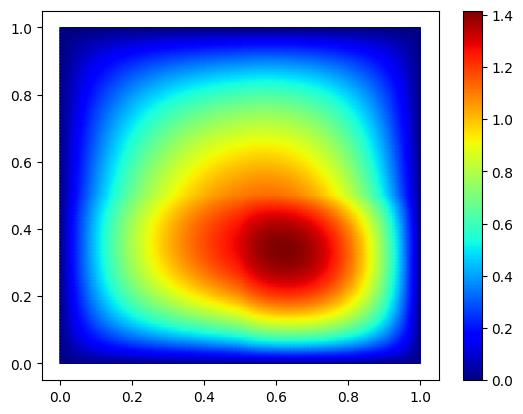

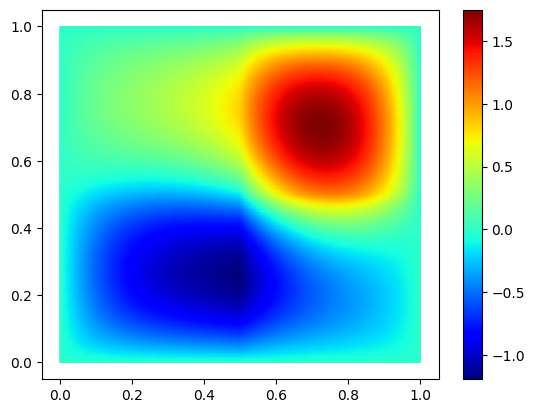

In [6]:

Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)
basis = Basis(m, ElementTriP1())
Phi=Construct_RB_greedy(NumberOfSnapshots=100,NumberOfModes=6,m=m)
ReducedBasis=Phi.T              
print(np.shape(ReducedBasis))
fig, ax = plt.subplots()

im=m.plot(ReducedBasis[:,0], ax=ax, shading='gouraud',colorbar=True)
fig, ax = plt.subplots()

m.plot(ReducedBasis[:,1], ax=ax, shading='gouraud',colorbar=True)


plt.show()

#### 4) Solve the reduced problem with the affine decomposition of the operators

In [73]:
# Greedy-Galerkin


def solve_fem_rom(A,b,I,mu, Phi,m):
    A11,A12,A21,A22=A
    # Restricted reduced basis
    Phi_I = Phi[:,I]
    ReducedBasis_I=... #P 
    
    # Reduced system
    # Interior DDL restriction
    A11_I = A11[I][:, I]
    A12_I = A12[I][:, I]
    A21_I = A21[I][:, I]
    A22_I = A22[I][:, I]
    b_I = b[I]

    A11r_I = ...
    A12r_I = ...
    A21r_I = ...
    A22r_I = ...

    A_rb_I = ...
    b_rb_I= ...

    coeff =...  #A_rb alpha=B_rb

    # ROM reconstructed
    u_rb_I = ...

    u_rb = np.zeros(A11.shape[0]) # 0 at the boundary 
    u_rb[I] = u_rb_I
    return u_rb

strong Greedy
Time : 0.003924369812011719 secondes


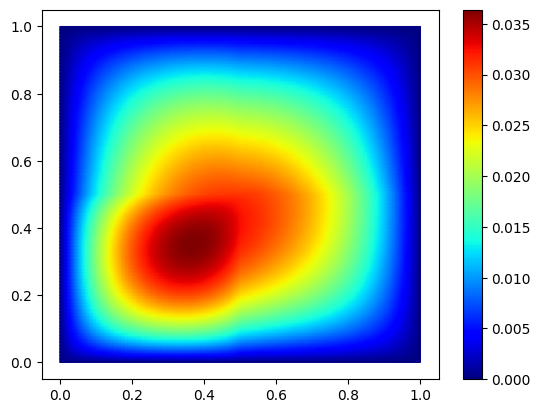

In [75]:
mu = (1,2,3,4)
Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)
basis = Basis(m, ElementTriP1())
I=get_interior_dofs(basis)
A11,A12,A21,A22, b, basis = FEMassembling(m)
Phi=Construct_RB_greedy(NumberOfSnapshots=100,NumberOfModes=6,m=m)                                                                                 
start = time.time()                                                                                                             
                                                                                                        
u_proj=solve_fem_rom([A11,A12,A21,A22],b,I,mu, Phi,m)
end = time.time()                                                                                                            
print("Time :", end - start, "secondes")
fig, ax = plt.subplots()

m.plot(u_proj, ax=ax, shading='gouraud',colorbar=True)



plt.show()

#### 5) Plot the convergence for one test parameter mu=[1,2,3,4]

n 20
strong Greedy
n 30
strong Greedy
n 40
strong Greedy
n 50
strong Greedy


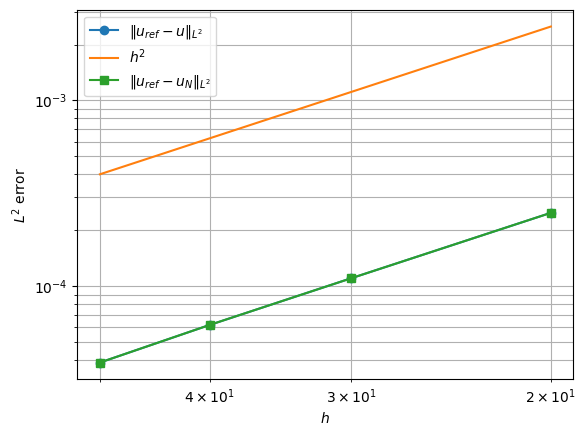

In [77]:
#### Convergence

mu = [1,2,3,4]

err_true=[]
err_rom=[]
hs=[]

m_ref = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, 250 + 1),
    np.linspace(0.0, 1.0, 250 + 1)
)

# ref solution (test with nx=ny=250)
A11_ref, A12_ref,A21_ref,A22_ref, b_ref, basis_ref = FEMassembling(m_ref)
U_ref = FEMsolve(A11_ref, A12_ref,A21_ref,A22_ref,b_ref, basis_ref, mu)

Xref = basis_ref.doflocs              # shape = (2, ndof)
L2=massMatrix.assemble(basis_ref)
# grid sizes to test
Ns = [20, 30, 40, 50]  

for n in Ns:
    print("n",n)
    m = ...
    basis = ...
 
    A11,A12,A21,A22, b, basis = ...
    U = ... # FEM solution
    
    Phi=...
    I=get_interior_dofs(basis)
    Urom=solve_fem_rom([A11,A12,A21,A22],b,I,mu, Phi,m)

    # Interpolation on ref mesh: 
    
    Uinterp=basis.interpolator(U)
    U_on_mesh_ref=Uinterp(Xref)

    Urominterp=basis.interpolator(Urom)
    Urom_on_mesh_ref=Urominterp(Xref)

    
    ## print L2 error
    true_error = ...
   
    l2_true_error=...
    #print(l2_true_error)
    rom_error = ...
    l2_rom_error=...


    err_true.append(l2_true_error)
    err_rom.append(l2_rom_error)

# ---------------------------
# Plot log-log convergence
# ---------------------------
hs = np.array(Ns)
err_true = np.array(err_true)
err_rom = np.array(err_rom)

plt.figure()
plt.loglog(hs, err_true, "o-", label=r"$\|u_{ref}-u\|_{L^2}$")
plt.loglog(hs, 1/(hs**2), "-", label=r"$h^2$")
plt.loglog(hs, err_rom, "s-", label=r"$\|u_{ref}-u_N\|_{L^2}$")
plt.gca().invert_xaxis()  # optional: smaller h to the right
plt.xlabel(r"$h$")
plt.ylabel(r"$L^2$ error")
plt.grid(True, which="both")
plt.legend()
plt.show()


## Part II: Aposteriori
#### 1) Plot the convergence for one test parameter mu=[1,2,3,4] with aposteriori error estimate 
$\|r_N\|_V^2 =r^T M_V^{-1} r$ where $M_V=A1+A2+A3 + A4$ (= diffusion(u,v,w))

In [87]:
from scipy.sparse.linalg import spsolve

def alpha_LB(mu):
    """
    Lower bound of a
    """
    return ...



def Construct_Delta_N(solve_XI,I,Phi, Ai_I_list, B_I, mu,basis):
    ## GLOBAL DELTA
    # Full matrix
    A11_I, A12_I,A21_I,A22_I=Ai_I_list
    A_I = mu[0] * A11_I + mu[1] * A12_I + mu[2] * A21_I + mu[3] * A22_I

    # Restricted reduced basis
    Phi_I = Phi[:,I]
    ReducedBasis_I=np.array(Phi_I).T #P 
    
    # Reduced system
    A_rb = ReducedBasis_I.T @ A_I @ ReducedBasis_I   
    B_rb = ReducedBasis_I.T @ B_I

    coeff =np.linalg.solve(A_rb, B_rb) #A_rb alpha=B_rb

    # ROM reconstructed
    u_rb_I = ReducedBasis_I@coeff
    if basis!= None:
        u_rb = np.zeros(basis.N) # 0 at the boundary 
        u_rb[I] = u_rb_I
    
    # Interior residual
    r_I = B_I - A_I@u_rb_I
    
    # Dual norm of the residual : sqrt(r^T X^{-1} r)
    # z= X_I^{-1} r_I
    z = solve_XI(r_I)
    # Estimator without alpha_LB
    dual_norm = np.sqrt(np.abs(r_I @ z))
    Delta_N = dual_norm / alpha_LB(mu)
    return u_rb, dual_norm, Delta_N



### WITH OFFLINE/ONLINE STRATEGY

def offline_residual_data(solve_KI, I, Phi, A_I_list, l_I):
    """
     offline quantities :
      LKL[k,q] = l_k^T K^{-1} l_q
      PAKAP[k,q] = P^T A_k^T K^{-1} A_q P
      PAKL[k,q] = P^T A_k^T K^{-1} l_q
      A_rb[q] = P^T A_q P
      l_rb[q] = P^T l_q
    ----------
    solve_KI : solve_KI(r) returns K_I z = r
    I : interior indices 
    Phi : RB 
    A_I_list : list [A1_I, ..., A_Qa_I]
    l_I
    ------
    Return dict with offline objects
    """

    # RB at the interior ddl 
    P = ...
    nI, N = P.shape
    Qa = len(A_I_list)
    Ql = 1

    # Offline operators reduction
    A_rb_list = ...
    l_rb = ...

    # 1) LKL[k,q] = l_k^T K^{-1} l_q
    # K z= l_q
    ...
    LKL = ...

    # 2) PAKAP[k,q] = P^T A_k^T K^{-1} A_q P
    PAKAP = np.zeros((Qa, Qa, N, N))
    ...
        

    # 3) PAKL[k,q] = P^T A_k^T K^{-1} l_q
    PAKL = [] # or np.zeros((Qa,  N))

    for k in range(Qa):
        # K z= l_q
        PAKL.append(...)   # shape (N,)

    return {
        "P": P,
        "A_rb_list": A_rb_list,
        "l_rb": l_rb,
        "LKL": LKL,
        "PAKAP": PAKAP,
        "PAKL": PAKL
    }

def online_residual_estimator(offline, I,theta_a, basis=None):
    
    P = offline["P"]
    A_rb_list = offline["A_rb_list"]
    l_rb = offline["l_rb"]
    LKL = offline["LKL"]
    PAKAP = offline["PAKAP"]
    PAKL = offline["PAKL"]
    Qa = 4
    Ql = 1

    # Reduced system
    A_rb = ...
    alpha =...

    # Reconstruction
    u_rb_I = ...
    u_rb = None
    
    if basis is not None:
        u_rb = np.zeros(basis.N)
        u_rb[I] = u_rb_I

    
    term_ll = ...

    term_aa = 0.0
    for q in range(Qa):
        for k in range(Qa):
            term_aa += ...

    term_la = 0.0
    
    for k in range(Qa):
        term_la += ...

    dual_norm_sq = ...
    dual_norm = np.sqrt(np.abs(dual_norm_sq))

    Delta_N = dual_norm / ...

    return u_rb, dual_norm, Delta_N
    

In [88]:
#### Convergence

mu = [1,2,3,4]
## test with N=5 and 15 reduced basis functions
err_fem_H10=[]
err_rom_H10=[]
hs=[]
err_true_X = []
estimator = []
effectivity = []

m_ref = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, 250 + 1),
    np.linspace(0.0, 1.0, 250 + 1)
)

# ref solution (test with nx=ny=250)
A11_ref, A12_ref,A21_ref,A22_ref, b_ref, basis_ref = FEMassembling(m_ref)
U_ref = FEMsolve(A11_ref, A12_ref,A21_ref,A22_ref,b_ref, basis_ref, mu)

Xref = basis_ref.doflocs              # shape = (2, ndof)
L2=massMatrix.assemble(basis_ref)
K=diffusion.assemble(basis_ref)

# grid sizes to test
Ns = [20,30,40,50]  


# -------------------------------------------------
#  convergence
# -------------------------------------------------


for n in Ns:
    print("n",n)
    m = MeshTri.init_tensor(
        np.linspace(0.0, 1.0, n + 1),
        np.linspace(0.0, 1.0, n + 1)
    )
    basis = Basis(m, ElementTriP1())
 
    A11,A12,A21,A22, b, basis = FEMassembling(m)
    U = FEMsolve(A11,A12,A21,A22,b,basis,mu) # FEM solution

    # Interpolation on ref mesh: 
    
    Uinterp=basis.interpolator(U)
    U_on_mesh_ref=Uinterp(Xref)

    Phi=...

    # ROM + certification
    I = get_interior_dofs(basis)
    X_current_mesh=A11+A12+A21+A22
    X_I = X_current_mesh[I][:, I]
    solve_XI = factorized(X_I.tocsc())

    # Interior DDL restriction
    A11_I = A11[I][:, I]
    A12_I = A12[I][:, I]
    A21_I = A21[I][:, I]
    A22_I = A22[I][:, I]
    b_I = b[I]
    
    
    offline = offline_residual_data(...)

    Urom, dual_norm, Delta_N = online_residual_estimator( ...  )
    
    urom_interp = basis.interpolator(Urom)
    Urom_on_mesh_ref = urom_interp(Xref) 

    ## print error
    fem_error = np.abs(...)
    H10_fem_error=np.sqrt(...)
    err_fem_H10.append(...)
    
    rom_error = np.abs(...)
    H10_rom_error=np.sqrt(...)
    err_rom_H10.append(...)

    # -------------------------
    # True residual error in X norm
    # -------------------------
    rom_error = np.abs(U - Urom)
    
    err_X=np.sqrt(rom_error@X_current_mesh.dot(rom_error))
    
    err_true_X.append(err_X)
    estimator.append(Delta_N)

    eff = ...
    effectivity.append(eff)

    print(f"  ||u_ref - u_h||_X = {H10_fem_error:.3e}")
    print(f"  ||u_ref - u_N||_X = {H10_rom_error:.3e}")
    print(f"  ||u_h - u_N||_X    = {err_X:.3e}")
    print(f"  ||r_N||_X'         = {dual_norm:.3e}")
    print(f"  Delta_N(mu)        = {Delta_N:.3e}")
    print(f"  effectivity        = {eff:.3e}")

n 20
strong Greedy
  ||u_ref - u_h||_X = 8.462e-03
  ||u_ref - u_N||_X = 8.464e-03
  ||u_h - u_N||_X    = 3.505e-04
  ||r_N||_X'         = 9.730e-04
  Delta_N(mu)        = 9.730e-04
  effectivity        = 2.776e+00
n 30
strong Greedy
  ||u_ref - u_h||_X = 5.356e-03
  ||u_ref - u_N||_X = 5.356e-03
  ||u_h - u_N||_X    = 9.889e-05
  ||r_N||_X'         = 2.828e-04
  Delta_N(mu)        = 2.828e-04
  effectivity        = 2.859e+00
n 40
strong Greedy
  ||u_ref - u_h||_X = 3.810e-03
  ||u_ref - u_N||_X = 3.830e-03
  ||u_h - u_N||_X    = 6.270e-04
  ||r_N||_X'         = 1.628e-03
  Delta_N(mu)        = 1.628e-03
  effectivity        = 2.597e+00
n 50
strong Greedy
  ||u_ref - u_h||_X = 3.470e-03
  ||u_ref - u_N||_X = 3.449e-03
  ||u_h - u_N||_X    = 2.072e-04
  ||r_N||_X'         = 6.233e-04
  Delta_N(mu)        = 6.233e-04
  effectivity        = 3.007e+00


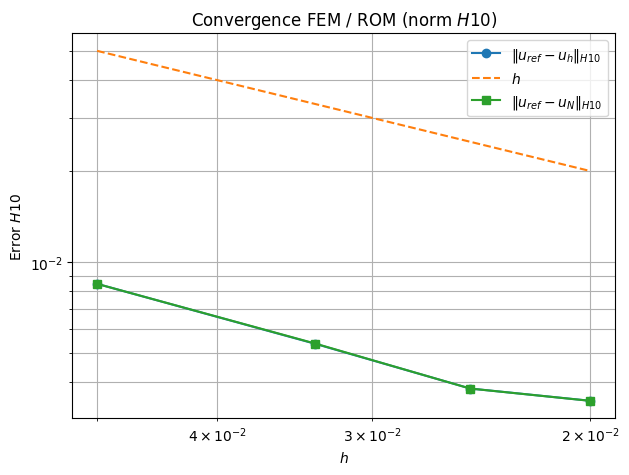

In [84]:
hs = 1./np.array(Ns)

err_fem_H10 = np.array(err_fem_H10)
err_rom_H10 = np.array(err_rom_H10)

plt.figure(figsize=(7, 5))
plt.loglog(hs, err_fem_H10, "o-", label=r"$\|u_{ref}-u_h\|_{H10}$")
plt.loglog(hs, hs, "--", label=r"$h$")
plt.loglog(hs, err_rom_H10, "s-", label=r"$\|u_{ref}-u_N\|_{H10}$")

plt.gca().invert_xaxis()
plt.xlabel(r"$h$")
plt.ylabel(r"Error $H10$")
plt.grid(True, which="both")
plt.legend()
plt.title("Convergence FEM / ROM (norm $H10$)")
plt.show()


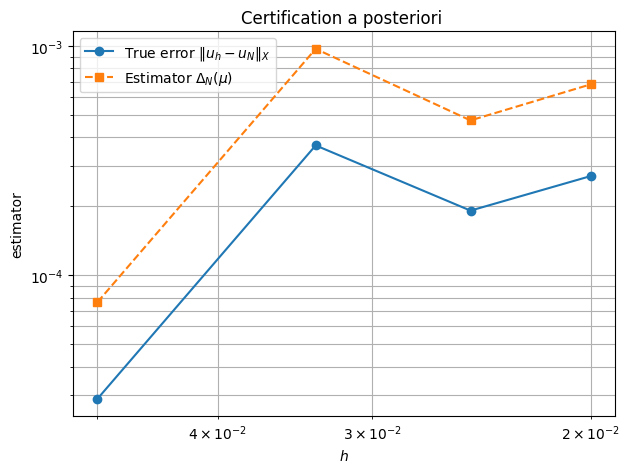

In [85]:

err_true_X = np.array(err_true_X)
estimator = np.array(estimator)
effectivity = np.array(effectivity)

plt.figure(figsize=(7, 5))
plt.loglog(hs, err_true_X, "o-", label=r"True error $\|u_h-u_N\|_X$")
plt.loglog(hs, estimator, "s--", label=r"Estimator $\Delta_N(\mu)$")

plt.gca().invert_xaxis()
plt.xlabel(r"$h$")
plt.ylabel(r"estimator")
plt.grid(True, which="both")
plt.legend()
plt.title("Certification a posteriori ")
plt.show()

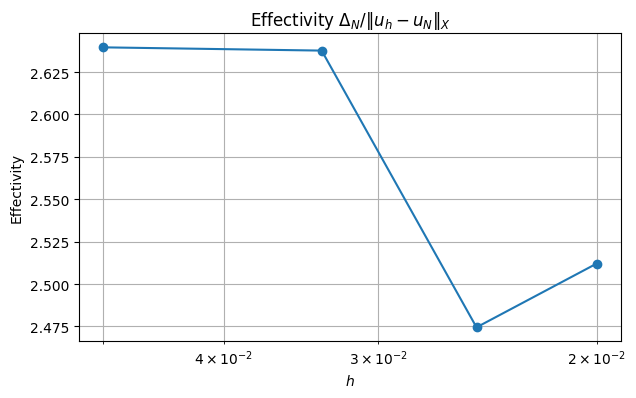

In [86]:
plt.figure(figsize=(7, 4))
plt.semilogx(hs, effectivity, "o-")
plt.gca().invert_xaxis()
plt.xlabel(r"$h$")
plt.ylabel("Effectivity")
plt.grid(True, which="both")
plt.title(r"Effectivity $\Delta_N / \|u_h-u_N\|_X$")
plt.show()

#### 2) Weak Greedy: Add aposteriori error estimate to greedy algorithm 
$\|r_N\|_V^2 =r^T M_V^{-1} r$ where $M_V=A1+A2+A3 + A4$ (= diffusion(u,v,w))

In [93]:
""" Greedy """


print("-----------------------------------")
print("        Offline                    ")
print("-----------------------------------")
def gram_schmidt_L2(u, basis_list, L2):
    # u - sum_k (u,Phi) Phi
    w = u.copy()

    for phi in basis_list:
        coeff = np.dot(w,L2.dot( phi))
        w -= coeff * phi

    norm_w = np.sqrt(np.dot(w,L2.dot( w)))
    if norm_w < 1e-12:
        return None
    
    return w / norm_w


def Construct_RB_weak_greedy(NumberOfSnapshots=100,NumberOfModes=20,m=m):
    
    basis = Basis(m, ElementTriP1())
    I = get_interior_dofs(basis)
    L2=massMatrix.assemble(basis)

    #print("number of modes: ",NumberOfModes)
    A11,A12,A21,A22, b, basis = FEMassembling(m)
    
    X = A11+A12+A21+A22   # Matrix for the norm ||.||_X
    X_I = X[I][:, I]
    solve_XI = factorized(X_I.tocsc())

    # Interior DDL restriction
    A11_I = A11[I][:, I]
    A12_I = A12[I][:, I]
    A21_I = A21[I][:, I]
    A22_I = A22[I][:, I]
    b_I = b[I]
    
    Params=[]
    for i in range(NumberOfSnapshots):
        mu = [...]  #random coefficient in [1, 10] 
        Params.append(...)

    U0=FEMsolve(A11,A12,A21,A22,  b, basis, Params[0])
    ReducedBasis=np.zeros((NumberOfModes,np.shape(U0)[0])) #initialization
    U0=U0.flatten()
    ReducedBasis[0,:]=... #first basis function = random first parameter or first snapshot in the list  
    selected_indices=[...] # Index selected in NumberOfSnapshots
    
    List_basis=[ReducedBasis[0,:]] #list of basis functions already generated  
    L2_basis=[L2.dot(List_basis[0])] # for the scalar product a_k=(u,Phi_k)
    
    """
    Goal : Find j ( or mu_j)  such that 
    mu_j= argmax_j Delta_j 
    """
    for n in range(1,NumberOfModes):
        Greedy_best_score = - 1 # Greedy_best_score = max_j  Delta_j
        best_index = None # selected index j for u_j
    
        # HERE = OFFLINE PART OF DELTA 
        for j in range(NumberOfSnapshots): 
            if not (j in selected_indices): #if index not yet in the reduced basis 
                mu=...
                ,_,Delta_j=... #ONLINE PART OF DELTA

                Greedy_score=...
                
                if Greedy_score > ...: 
                    Greedy_best_score = ...
                    best_index = ...
                    
                
        selected_indices.append(...) #adding the corresponding j in the list
        U=...
        List_basis.append(gram_schmidt_L2(U, List_basis, L2))#orthonormalization in L2
     
        ReducedBasis[n,:]=List_basis[-1] 
    

    #orthogonality test
    
    return ReducedBasis,Params
  

-----------------------------------
        Offline                    
-----------------------------------


In [ ]:
Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)
basis = Basis(m, ElementTriP1())
Phi,_=Construct_RB_weak_greedy(NumberOfSnapshots=100,NumberOfModes=6,m=m)
ReducedBasis=Phi.T              
print(np.shape(ReducedBasis))
fig, ax = plt.subplots()

im=m.plot(ReducedBasis[:,0], ax=ax, shading='gouraud',colorbar=True)
fig, ax = plt.subplots()

m.plot(ReducedBasis[:,1], ax=ax, shading='gouraud',colorbar=True)


plt.show()

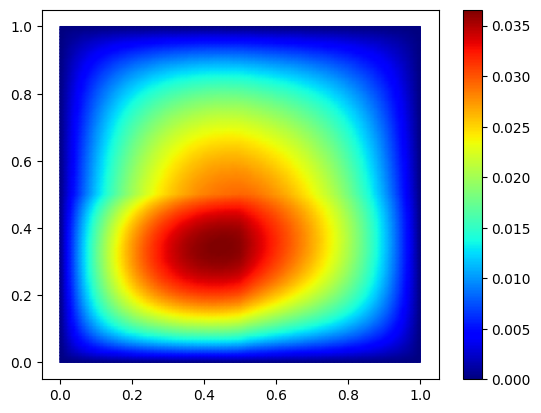

In [41]:
mu = (1,2,3,4)

Nx=Ny = 100
m = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, Nx + 1),
    np.linspace(0.0, 1.0, Ny + 1)
)
basis = Basis(m, ElementTriP1())
A11,A12,A21,A22, b, basis = FEMassembling(m)

u_proj=solve_fem_rom(A11,A12,A21,A22,mu, Phi,m)

fig, ax = plt.subplots()

m.plot(u_proj, ax=ax, shading='gouraud',colorbar=True)



plt.show()

In [ ]:

mu = [1,2,3,4]

err_true=[]
err_rom=[]
hs=[]
m_ref = MeshTri.init_tensor(
    np.linspace(0.0, 1.0, 250 + 1),
    np.linspace(0.0, 1.0, 250 + 1)
)

A11_ref, A12_ref,A21_ref,A22_ref, b_ref, basis_ref = FEMassembling(m_ref)
U_ref = FEMsolve(A11_ref, A12_ref,A21_ref,A22_ref,b_ref, basis_ref, mu)


# Ref interopolant
u_ref_interp = basis_ref.interpolator(U_ref)


#  grid sizes to test
Ns = [20, 30, 40, 50] 
for n in Ns:
    print("n",n)
    m = MeshTri.init_tensor(
        np.linspace(0.0, 1.0, n + 1),
        np.linspace(0.0, 1.0, n + 1)
    )
    basis = Basis(m, ElementTriP1())

    A11,A12,A21,A22, b, basis = ...
    U = ...
    
    Phi,_=...

    L2=massMatrix.assemble(basis)

    Uproj=...

     #Interpolated solution
    X = basis.doflocs              # shape = (2, ndof)
    U_ref_on_mesh = u_ref_interp(X)

    ## print error
    true_error = ...
    l2_true_error=...

    rom_error = ...
    l2_rom_error=...


   # L2 errors 
    err_true.append(l2_true_error)
    err_rom.append(l2_rom_error)

# ---------------------------
# Plot log-log convergence
# ---------------------------
hs = np.array(Ns)
err_true = np.array(err_true)
err_rom = np.array(err_rom)

plt.figure()
plt.loglog(hs, err_true, "o-", label=r"$\|u_{ref}-u\|_{L^2}$")
plt.loglog(hs, 1/(hs**2), "-", label=r"$h^2$")
plt.loglog(hs, err_rom, "s-", label=r"$\|u_{ref}-u_N\|_{L^2}$")
plt.gca().invert_xaxis()  # optional: smaller h to the right
plt.xlabel(r"$h$")
plt.ylabel(r"$L^2$ error")
plt.grid(True, which="both")
plt.legend()
plt.show()